In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
import os
import string

# 設置中文字體
mpl.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei']

def load_data(file_path, rows, cols):
    """
    【10x11 魯棒模式】解析 ASCII 藝術檔案。
    - 讀取 ROWS+1 行數據 (例如 11 行)，將模式間的單個空行視為額外行。
    - 數據處理後，返回 ROWS x COLS (10x10) 的有效數據。
    """
    # 實際讀取的行數
    READ_ROWS = rows + 1  # 例如：10 + 1 = 11
    
    # 每個模式的總數據點數 (11 * 10 = 110)
    TOTAL_READ_SIZE = READ_ROWS * cols 
    
    patterns_list = []
    current_pattern_data = []
    
    # ... (錯誤檢查和檔案讀取保持不變) ...
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            
        for line_num, line in enumerate(lines, 1):
            
            line_cleaned = line.strip('\n') 
            line_stripped = line_cleaned.strip()
            is_empty_data_line = not line_stripped
            
            row_data = [0] * cols # 初始化一行 COLS 個 0
            
            if is_empty_data_line:
                 # 遇到空行 -> 這是 11 行中的一員，補 0
                 # row_data 已經是 [0] * cols，無需操作
                 pass 
            else:
                 # 遇到非空行 -> 逐字符解析前 COLS 個字符
                 
                 for i in range(cols):
                     try:
                         # 僅使用 line_cleaned 進行索引 (不進行任何偏移修正)
                         char = line_cleaned[i]
                         
                         if char == '1':
                             row_data[i] = 1
                         # 否則 (char 是空格/其他)，row_data[i] 保持為 0
                             
                     except IndexError:
                         # 行寬不足，後續已經是 0，直接跳出
                         break

            # 累積數據點
            current_pattern_data.extend(row_data)
            
            # 立即檢查模式是否完成 (總點數達到 110)
            if len(current_pattern_data) == TOTAL_READ_SIZE:
                
                # 📌 關鍵步驟：忽略最後一行數據 (即分隔符)
                valid_pattern_data = np.array(current_pattern_data)[:-cols] # 忽略最後 cols (10) 個點
                patterns_list.append(valid_pattern_data)
                
                print(f"模式 #{len(patterns_list)} 完成，使用到 L{line_num}。")
                
                current_pattern_data = [] # 清空，準備收集下一個圖案
            
            elif len(current_pattern_data) > TOTAL_READ_SIZE:
                # 修正：如果數據超出，表示分隔符錯誤或連續空行被視為數據。
                # 這裡需要將 current_pattern_data 截斷到 TOTAL_READ_SIZE 的倍數
                
                # 為了避免複雜的截斷邏輯，我們只在末端處理
                pass


        # 處理文件結束時，可能不足 TOTAL_READ_SIZE 的不完整模式
        if len(current_pattern_data) >= cols: # 至少有 ROW=1 行數據
            # 如果數據量介於 110 到 219 之間 (例如多了一個不完整的模式)
            
            # 為了簡化，我們只處理不足 TOTAL_READ_SIZE 的情況
            if len(current_pattern_data) % TOTAL_READ_SIZE != 0:
                print(f"警告：檔案末端有不完整的數據 ({len(current_pattern_data)} 點)，已忽略。")
        
    except Exception as e:
        print(f"解析 ASCII 藝術檔案時發生錯誤：{e}")
        return None
    
    if not patterns_list:
        print("警告：未成功解析出任何完整圖案。請檢查檔案格式。")
        return None
        
    print(f"成功解析出 {len(patterns_list)} 個完整圖案。")
    # 將所有圖案堆疊成 N x M 矩陣 (N=100, M=模式數)
    return np.stack(patterns_list).T

# 將(0, 1)二元數據轉換為(-1, +1)二極性狀態
def bipolarize(patterns):
    return 2 * patterns - 1

# 將(-1, +1)二極性狀態轉換回(0, 1)二元數據
def unipolarize(bipolar_pattern):
    return (bipolar_pattern + 1) // 2

In [ ]:
## 2. 訓練階段：權重矩陣計算
# 使用Hebbian Rule計算Hopfield network的權重矩陣W
# W = sum(s_p * s_p.T) - M * I(使用外部積法則)
def train_hopfield(biopolar_pattern):
    N = biopolar_pattern.shape[0]   # 神經元數量
    M = biopolar_pattern.shape[1]   # 模式數量

    W = np.zeros((N, N))

    # 疊加所有模式的外部積
    for p in range(M):
        s_p = biopolar_pattern[:, p].reshape(-1, 1)    # N x 1向量
        W += s_p @ s_p.T    # 外部積，得到N x N矩陣

    # 設置對角線元素為0 (Wii = 0)
    np.fill_diagonal(W, 0)

    return W

In [2]:
## 2. 訓練階段：權重矩陣計算(升級版)
import numpy as np
from numpy.linalg import pinv

# 使用pseudo-inverse法則計算Hopfield network的權重矩陣W
# W = S @ (S.T)
def train_hopfield_pseudoinverse(bipolar_patterns):
    N = bipolar_patterns.shape[0]   # 神經元數量 (108)
    M = bipolar_patterns.shape[1]   # 模式數量 (3或4)

    # S : N x M矩陣，其中每行都是一個模式
    S = bipolar_patterns

    # 1. 計算S的轉置S.T的pseudo-inverse(pinv)
    # pinv(S.T)的維度是M x N
    try:
        S_pinv = pinv(S)
    # 如果矩陣失敗 (一般很少見，除非數據的維度有問題)
    except np.linalg.LinAlgError as e:
        print(f"pseudo-inverse計算失敗：{e}")
        return np.zeros((N, N))
    
    # 2. 計算權重矩陣 W = S @ S_pinv_T
    # (N x M) @ (M x N) = N x N 矩陣
    W = S @ S_pinv

    # 3. 設置對角線元素為0 (Wii =  0)
    np.fill_diagonal(W, 0)

    return W

In [3]:
##  3. 回憶階段：狀態迭代收斂
# 使用異步更新來回憶模式，直到收斂或達到最大疊代次數
def recall_pattern(W, initial_state, max_iter = 1000):
    N = W.shape[0]
    current_state = initial_state.copy()

    # 異步更新：隨機選擇N個神經元進行更新，確保在一個epoch內所有神經元都有機會被更新       
    for iteration in range(max_iter):
        previous_state = current_state.copy()

        update_order = list(range(N))
        random.shuffle(update_order)

        # 計算淨輸入 h_i = Sum(W_ij * s_j)，使用numpy的點積快速運算
        for i in update_order:
            net_input = W[i, :] @ current_state

            # 激活函數：Sign(h_i) -> 這裡的Sign(0)保持不變
            if net_input > 0:
                current_state[i] = 1
            elif net_input < 0:
                current_state[i] = -1
            # 否則(net_input == 0)狀態保持不變

        if np.array_equal(current_state, previous_state):
            print(f"收斂於第{iteration + 1}輪迭代")
            break
    
    return current_state

In [4]:
## 4. 顯示結果(簡單版)
# 使用Matplotlib顯示原始測試圖形和回憶後的結果
def display_patterns(original_pattern, recalled_pattern, rows, cols):
    fig, axes = plt.subplots(1, 2, figsize = (8, 4))

    # 轉換回(0, 1)矩陣進行顯示
    original_img = unipolarize(original_pattern).reshape(rows, cols)
    recalled_img = unipolarize(recalled_pattern).reshape(rows, cols)

    # 顯示原始測試圖形
    axes[0].imshow(original_img, cmap = "gray")
    axes[0].set_title("原始測試圖形 (輸入)")
    axes[0].axis("off")

    # 顯示回憶結果
    axes[1].imshow(recalled_img, cmap = "gray")
    axes[1].set_title("Hopfield回憶結果 (輸出)")
    axes[1].axis("off")

    plt.suptitle("Hopfield 網路聯想記憶結果")
    plt.tight_layout(rect = [0, 0.03, 1, 0.95])
    plt.show()

# 驗證最終狀態是否為虛偽記憶
def verify_spurious_state(final_state, training_bipolar):
    """
    Args:
        final_state (np.array): 網路回憶後的最終狀態向量 (N x 1)。
        training_bipolar (np.array): 所有的訓練模式 (N x M 矩陣)。
        
    Returns:
        tuple: (is_memory, matched_index)
            is_memory (bool): True 表示是記憶模式，False 表示是偽記憶。
            matched_index (int): 如果是記憶模式，返回匹配的索引；否則返回 -1。
    """
    M = training_bipolar.shape[1] # 模式數量
    
    for j in range(M):
        memory_Pj = training_bipolar[:, j]
        
        # 檢查輸出是否與任一記憶模式完全相同
        if np.array_equal(final_state, memory_Pj):
            # 成功收斂到一個真實記憶
            return True, j
            
    # 如果迴圈結束都未匹配，則視為偽記憶
    return False, -1

In [5]:
## 5. 主執行邏輯
def main_hopfield_baseline(training_file, testing_file, rows, cols):
    print(f"--- Hopfield 網路實作開始({rows}x{cols}圖形 ---)")
    N = rows * cols     # 神經元總數

    # 1. 載入訓練數據
    training_uni = load_data(training_file, rows, cols)
    if training_uni is None: return

    # 轉換為二極性格式
    training_bipolar = bipolarize(training_uni)
    print(f"成功載入{training_bipolar.shape[1]}個訓練模式")

    # 2. 訓練：計算權重矩陣W
    W = train_hopfield_pseudoinverse(training_bipolar)
    print(f"權重矩陣W計算完成(大小：{N} x {N})")
    
    # 3. 載入測試數據
    testing_uni = load_data(testing_file, rows, cols)
    if testing_uni is None: return

    # 測試集可能有多種模式，但是Hopfield一次處理一個
    for i in range(testing_uni.shape[1]):
        initial_state = bipolarize(testing_uni[:, i])

        print(f"\n--- 正在回憶第{i + 1}個測試圖形 ---")
        test_img = unipolarize(initial_state).reshape(rows, cols)
        print(f"輸入圖形的前 5 行 (0/1): \n{test_img[:5, :]}")
        # 4. 回憶：迭代收斂
        final_state = recall_pattern(W, initial_state)

        # === 📌 插入驗證功能：檢查偽記憶 ===
        is_memory, matched_index = verify_spurious_state(final_state, training_bipolar)
    
        if is_memory:
            print(f"✅ 驗證結果：成功收斂到訓練記憶 #{matched_index + 1}。")
        else:
            print("❌ 驗證結果：收斂到【虛偽記憶】或【錯誤記憶】。")
    
        # 5. 顯示結果
        display_patterns(initial_state, final_state, rows, cols)

--- Hopfield 網路實作開始(10x10圖形 ---)
模式 #1 完成，使用到 L11。
模式 #2 完成，使用到 L22。
模式 #3 完成，使用到 L33。
模式 #4 完成，使用到 L44。
模式 #5 完成，使用到 L55。
模式 #6 完成，使用到 L66。
模式 #7 完成，使用到 L77。
模式 #8 完成，使用到 L88。
模式 #9 完成，使用到 L99。
模式 #10 完成，使用到 L110。
模式 #11 完成，使用到 L121。
模式 #12 完成，使用到 L132。
模式 #13 完成，使用到 L143。
模式 #14 完成，使用到 L154。
模式 #15 完成，使用到 L165。
成功解析出 15 個完整圖案。
成功載入15個訓練模式
權重矩陣W計算完成(大小：100 x 100)
模式 #1 完成，使用到 L11。
模式 #2 完成，使用到 L22。
模式 #3 完成，使用到 L33。
模式 #4 完成，使用到 L44。
模式 #5 完成，使用到 L55。
模式 #6 完成，使用到 L66。
模式 #7 完成，使用到 L77。
模式 #8 完成，使用到 L88。
模式 #9 完成，使用到 L99。
模式 #10 完成，使用到 L110。
模式 #11 完成，使用到 L121。
模式 #12 完成，使用到 L132。
模式 #13 完成，使用到 L143。
模式 #14 完成，使用到 L154。
模式 #15 完成，使用到 L165。
成功解析出 15 個完整圖案。

--- 正在回憶第1個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 0 1 0 1 0 1 0 1 0]
 [0 0 0 1 0 1 0 0 0 1]
 [1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 0 0 1]
 [0 0 1 0 1 0 1 0 1 0]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #1。


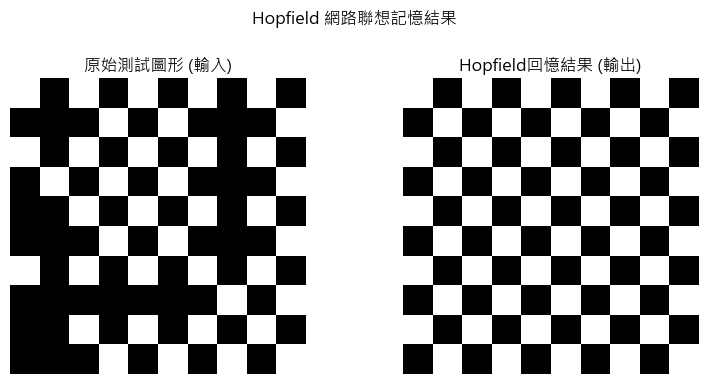


--- 正在回憶第2個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 1 0 0 1 1 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 1 1 0 0]
 [0 0 1 1 0 0 1 1 0 0]
 [1 1 0 0 1 1 0 0 1 1]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #2。


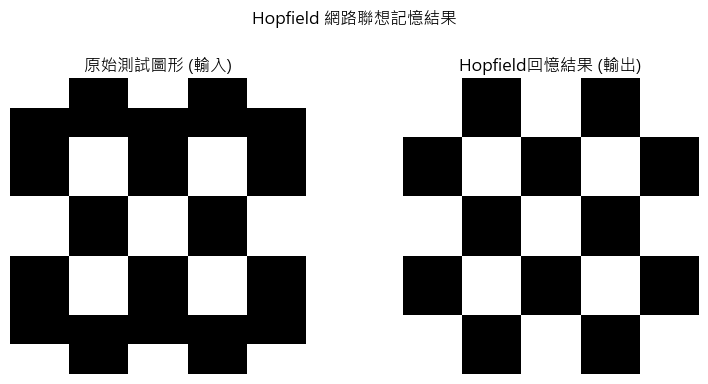


--- 正在回憶第3個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 1 1 1 1 0 0 0 0 0]
 [1 0 0 1 1 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #3。


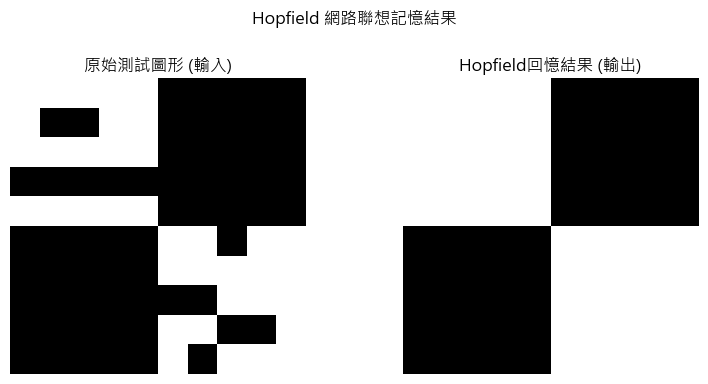


--- 正在回憶第4個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 0 0 1 0 0 1 0 0 1]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 1 0 0 0 0 0]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #4。


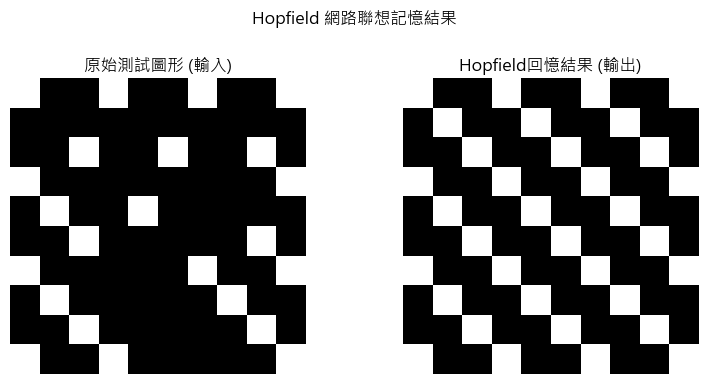


--- 正在回憶第5個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 0 1 1 1 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 1]
 [1 0 1 1 1 0 1 1 0 1]
 [1 0 0 0 0 0 0 1 0 1]
 [1 0 1 0 1 1 0 1 0 1]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #5。


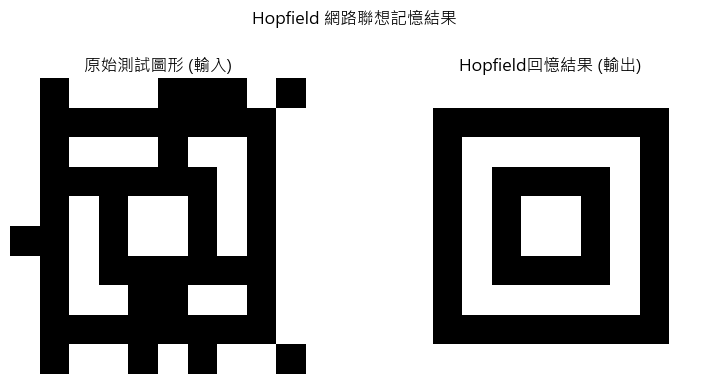


--- 正在回憶第6個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #6。


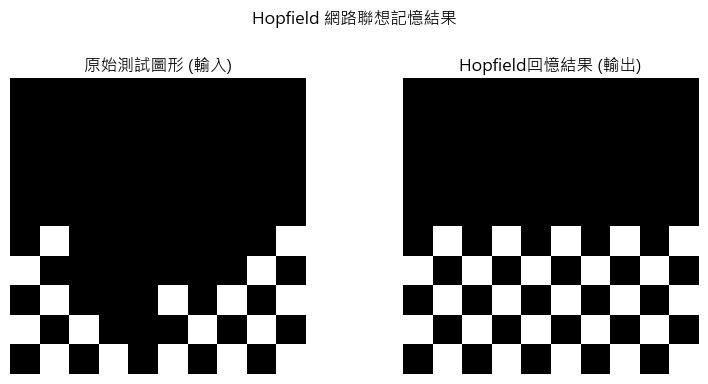


--- 正在回憶第7個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 0 1 0 1 0 1 0 1 0]
 [0 0 0 1 0 0 0 1 0 1]
 [1 0 1 0 0 0 1 0 1 0]
 [0 1 0 0 0 0 0 1 0 1]
 [1 0 0 0 0 0 0 0 1 0]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #1。


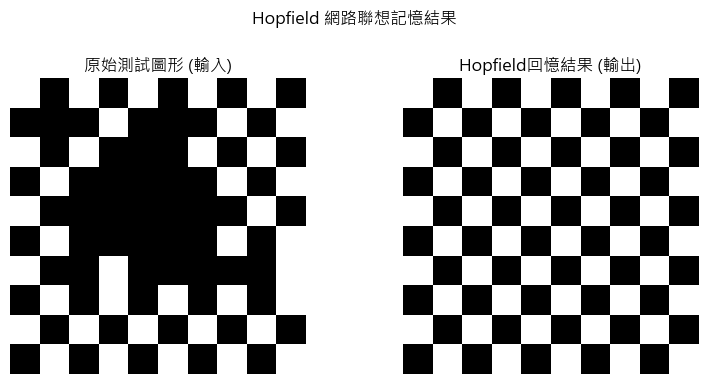


--- 正在回憶第8個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 1 0 0 1 0 0 0 0 1]
 [0 1 0 0 1 0 0 0 1 1]
 [0 0 1 0 1 0 1 1 0 1]
 [0 1 0 1 0 0 0 1 0 0]
 [1 0 0 0 1 0 0 1 1 1]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #8。


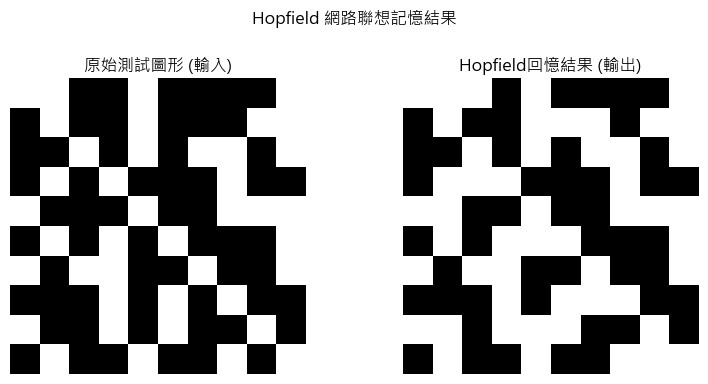


--- 正在回憶第9個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[0 0 0 0 1 1 0 0 1 1]
 [0 0 0 0 1 1 0 0 1 1]
 [0 0 0 1 0 0 1 1 0 0]
 [0 0 0 1 0 0 1 1 0 0]
 [1 1 0 0 1 1 0 0 0 1]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #2。


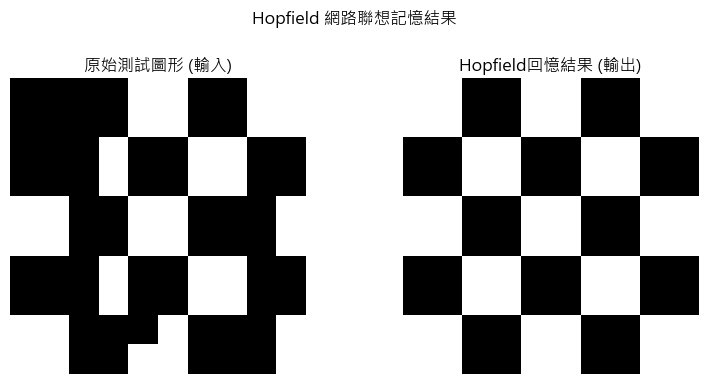


--- 正在回憶第10個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 1 0]
 [0 0 0 0 1 0 1 0 1 0]
 [1 0 0 0 1 0 1 0 1 0]
 [1 1 0 1 1 0 0 0 0 0]]
收斂於第3輪迭代
❌ 驗證結果：收斂到【虛偽記憶】或【錯誤記憶】。


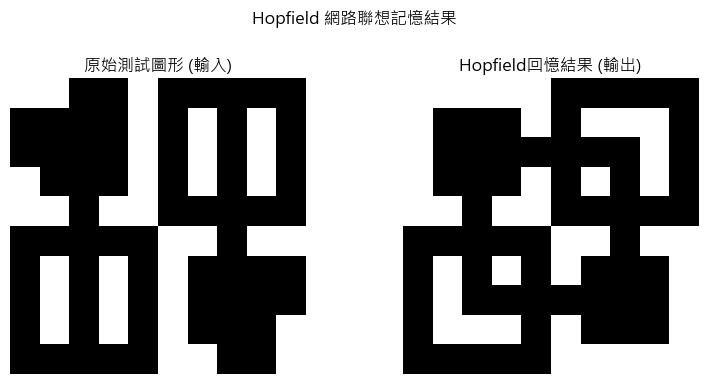


--- 正在回憶第11個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 1 0 1 1 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 0]
 [1 1 0 1 1 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]]
收斂於第3輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #3。


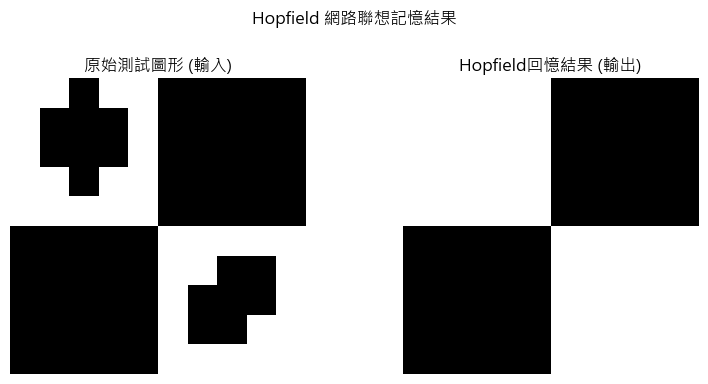


--- 正在回憶第12個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 0 0 1 1 1 1 0 0 1]
 [1 1 0 0 1 1 0 1 0 0]
 [1 0 1 0 0 0 1 0 1 0]
 [1 0 1 1 0 0 1 1 0 1]
 [0 1 1 1 1 0 0 1 0 1]]
收斂於第3輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #12。


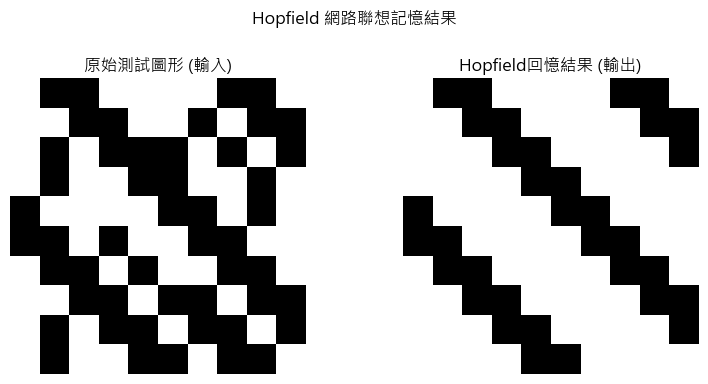


--- 正在回憶第13個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 0 0 1 0 0 1 0 0 1]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 1 0 0 1 0 0]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #4。


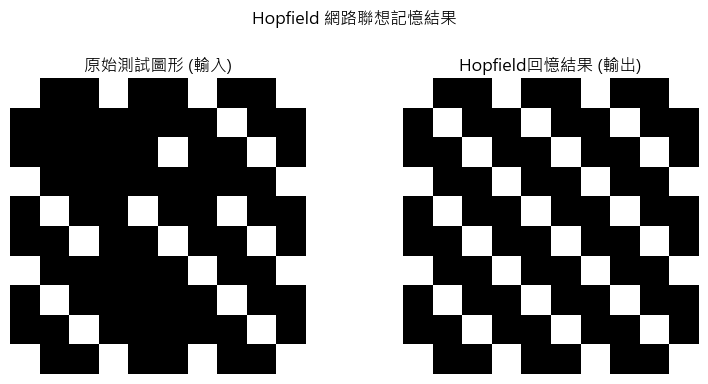


--- 正在回憶第14個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 1 1 1 1 1 1 1 1 1]
 [1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 1]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #14。


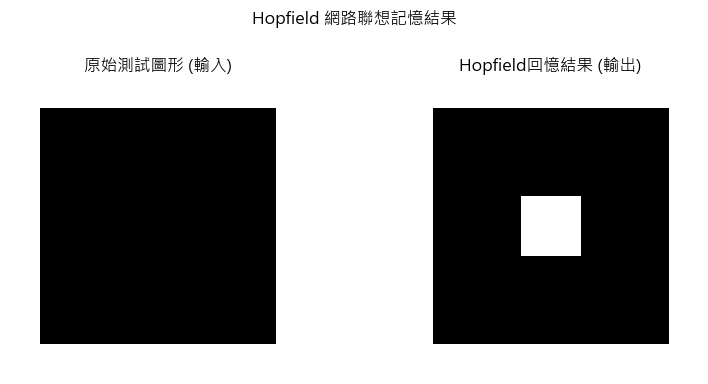


--- 正在回憶第15個測試圖形 ---
輸入圖形的前 5 行 (0/1): 
[[1 1 1 0 1 1 1 1 1 1]
 [1 0 0 0 0 0 0 0 0 1]
 [1 0 1 1 0 1 1 1 0 1]
 [1 0 1 0 0 0 0 1 0 1]
 [1 0 0 0 0 0 0 1 0 1]]
收斂於第2輪迭代
✅ 驗證結果：成功收斂到訓練記憶 #5。


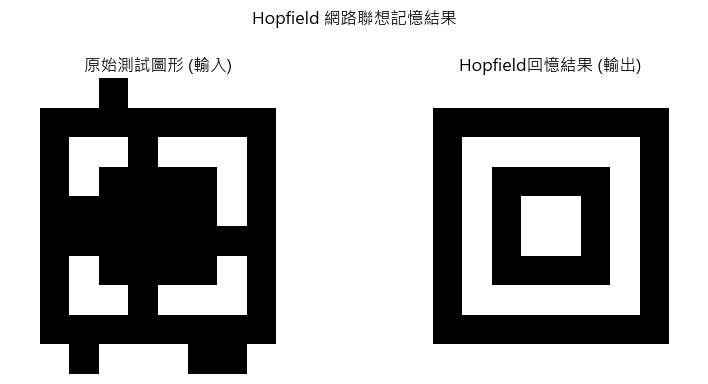

In [6]:
# 執行主程序
if __name__ == "__main__":
    # 基本要求參數
    ROWS = 10
    COLS = 10
    TRAINING_FILE = "./Hopfield_dataset/Bonus_Training.txt"
    TESTING_FILE = "./Hopfield_dataset/Bonus_Testing.txt"

    # 確保這些文件存在於程式碼目錄中
    main_hopfield_baseline(TRAINING_FILE, TESTING_FILE, ROWS, COLS)